
<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/9-Control_Variables.ipynb)

</div>






$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE -- Control Variables}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{Oct 24, 2025}\\\\\\
\text{Materials prepared by: Daniela Pinto Veizaga, Xiang Pan, and Xiang Gao}
\end{array}
$$

---

**Goals:**
1. Independence and Conditional Independence
2. Multiple Descriptive Regression and Multiple Causal Regression


# Independence and Conditional Independence

If the data-generating processes were not naturally randomizing treatment, we can seek to adjust the population in the treatment and control groups.

One adjustment method is through controlling or conditioning on other factors $C$ such that

\begin{equation}
S \perp U \ | \ C
\end{equation}

In this case, we can say that $S$ and $U$ are **conditionally independent** given $C$.

## Independence Recap

Usually,

\begin{align*}
P(X , Y) &= P(X ) \cdot P(Y| X ) ,\qquad (\text{or})\\
& = P(Y ) \cdot P(X | Y)

\end{align*}



Independence plays a central role in our arguments for the identification of causal parameters.

$$
P(X , Y) = P(X )\cdot P(Y )
$$

Also,

$$
P(Y|X) = P(Y) \ \ \text{and} \ \ P(X|Y) = P(X)
$$

If two variables are independent, then knowing the value of one variable does not provide additional information about the other.

Also, independent variables have a covariance of 0 and are, therefore, uncorrelated.
- Proof in lecture slides by showing $E[XY]=E[X]E[Y]$

We've seen that independence implies 0 covariance and uncorrelatedness.

However, the converse statement is false. Independence is not necessary for uncorrelatedness.

## Conditional Independence

Sometimes, we cannot say that $X$ and $Y$ are independent, but we can say that they are **conditionally independent**.



$$
P(X , Y | Z) = P(X |Z)\cdot P(Y |Z)
$$

Also,

$$
P(Y|X, Z) = P(Y|Z) \ \ \text{and} \ \ P(X|Y, Z) = P(X | Z)
$$

$X$ and $Y$ have no relationship if we account for the value taken by some other variable $Z$. For example, knowing $X$, if we already know $Z$, this does not influence our estimate of $Y$.

**Note:** Usually

$$
P(X , Y | Z) = P(X |Z)\cdot P(Y |Z,X)
$$


**Example: Height, Reading Ability, and Age**

**Setup:** Height ($X$) and reading ability ($Y$) are clearly related — babies are short and can’t read.

**But:** Once you condition on age ($Z$), height no longer tells you anything about reading ability.  
Among 20-year-olds, tall and short people read equally well.

**Conclusion:**

$$
P(\text{can read} \mid \text{Height}, \text{Age}) = P(\text{can read} \mid \text{Age})
$$

Height and reading ability are **conditionally independent** given age.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm

In [6]:
# simulate independent random variables
X_ind = np.random.randint(1, 7, 1000)  # Roll of die 1
Y_ind = np.random.randint(1, 7, 1000)  # Roll of die 2

# calculate covariance of independent variables
cov_ind = np.cov(X_ind, Y_ind)[0, 1]
print(f"Covariance of independent variables: {cov_ind:.3f}")

# simulate dependent variables
X_dep = np.random.randint(1, 10, 1000)
Y_dep = 2 * X_dep + np.random.normal(0, 1, 1000)
Z_dep = 2 * X_dep + np.random.normal(0, 1, 1000)

# calculate covariance of dependent variables
cov_dep = np.cov(Y_dep, Z_dep)[0, 1]
print(f"Covariance of dependent variables Y and Z: {cov_dep:.4f}")

# calculate covariance of dependent variables condition on X
for X_value in range(1, 10):
  cov_dep = np.cov(Y_dep[X_dep==X_value], Z_dep[X_dep==X_value])[0, 1]
  print(f"Covariance of dependent variables Y and Z condition on X = {X_value}: {cov_dep:.4f}")

Covariance of independent variables: -0.042
Covariance of dependent variables Y and Z: 26.7327
Covariance of dependent variables Y and Z condition on X = 1: 0.0620
Covariance of dependent variables Y and Z condition on X = 2: 0.0344
Covariance of dependent variables Y and Z condition on X = 3: 0.0340
Covariance of dependent variables Y and Z condition on X = 4: 0.0822
Covariance of dependent variables Y and Z condition on X = 5: -0.0176
Covariance of dependent variables Y and Z condition on X = 6: -0.0015
Covariance of dependent variables Y and Z condition on X = 7: 0.0699
Covariance of dependent variables Y and Z condition on X = 8: -0.0457
Covariance of dependent variables Y and Z condition on X = 9: -0.1019


The results illustrate the ideas of **independence**, **dependence**, and **conditional independence** using covariance as a measure of association.

1. **Independent Variables (Two Dice Rolls)**  
   The covariance between the two dice rolls is approximately **0**.  
   This makes sense because the outcome of one die provides no information about the other — they are **independent**.

   > Covariance of independent variables: ≈ 0

2. **Dependent Variables (Shared Cause)**  
   The covariance between hits($Y$) and hits($Z$) is relatively large and positive.  
   Both hits($Y$) and hits($Z$) depend on the same underlying variable hits($X$).

   > Covariance of dependent variables hits($Y$), hits($Z$): large positive value

3. **Conditional Independence**  
   When we compute the covariance of hits($Y$) and hits($Z$) **within each fixed value of hits($X$)**, the covariance drops to values close to **0**.  
   This means that once we **control for hits($X$)**, the apparent relationship between hits($Y$) and hits($Z$) disappears.

   > hits($Y$) and hits($Z$) are **conditionally independent given hits($X$)**.


# Multiple Descriptive and Causal Regression

## Multiple Descriptive Regression (Matrix Form)

$$
Y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \varepsilon
$$

The multiple linear regression model can be written in matrix form as:

$$
\begin{bmatrix}
Y_1 \\
Y_2 \\
\vdots \\
Y_n
\end{bmatrix}_{n \times 1}
=
\begin{bmatrix}
1 & X_{11} & X_{21} & \cdots & X_{k1} \\
1 & X_{12} & X_{22} & \cdots & X_{k2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & X_{1n} & X_{2n} & \cdots & X_{kn}
\end{bmatrix}_{n \times (k+1)}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_k
\end{bmatrix}_{(k+1) \times 1}
+
\begin{bmatrix}
\varepsilon_1 \\
\varepsilon_2 \\
\vdots \\
\varepsilon_n
\end{bmatrix}_{n \times 1}
$$

This can be rewritten more compactly as:

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

where:
- **$ \mathbf{y} $** is the $ n \times 1 $ vector of observed outcomes,  
- **$ \mathbf{X} $** is the $ n \times (k+1) $ design matrix (including a column of ones for the intercept),  
- **$ \boldsymbol{\beta} $** is the $ (k+1) \times 1 $ vector of coefficients, and  
- **$ \boldsymbol{\varepsilon} $** is the $ n \times 1 $ vector of residuals (errors).

With linear algebra and matrix calculus, we can obtain the coefficient vector $ \boldsymbol{\beta} $, which equals:

$$
\boldsymbol{\beta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$


## Causal Regression

**Revisiting All Causes Model**

All causes model:

$$Y(S, U)$$

where $Y$ is the outcome, $S$ is the state of the world, and $U$ is other factors we observe that influence $Y$.

Also, for simplicity, consider $S$ as a binary treatment variable (0 or 1).

Causal quantities of interest:

$$
\begin{align}
\text{ATE} &= E[Y(S=1, U) - Y(S=0, U)]\\
\text{ATT} &= E[Y(S=1, U) - Y(S=0, U)|S=1]\\
\text{ATU} &= E[Y(S=1, U) - Y(S=0, U)|S=0]
\end{align}
$$

**Fundamental problem of causal inference**: we only get to see one of $Y(S=1, U)$ and $Y(S=0, U)$.

Identification is the process where we reduce these equations involving unobserved variables to observed data.

If we have $U \perp S$, then we can use descriptive variables to estimate the treatment effect.

**Recall the simple causal regression**

We start from a simple causal model:

$$
Y(S, U) = \alpha_0 + \alpha_1 S + U
$$

Here:

- **$Y$**: outcome  
- **$S$**: treatment (e.g., binary — 0 or 1)  
- **$U$**: unobserved confounders — other factors that affect $Y$

**The problem:**  
If $S$ and $U$ are correlated (i.e., $S \not\!\perp U$), then our estimate of $\alpha_1$ (the causal effect of $S$) will be **biased**.

**First: The Role of the Control Variable $C$**


Suppose there exists a variable $C$ such that:

$$
S \perp U \mid C
$$

This means that once we **control for $C$**, the treatment $S$ is as good as random with respect to $U$.

**Intuitively:**  
$C$ “absorbs” all the systematic ways in which $S$ and $U$ are related.  
Within each level of $C$, treatment assignment behaves like random assignment.

This gives us:

$$
\mathbb{E}[U \mid S, C] = \mathbb{E}[U \mid C]
$$


**Second: Define a New Variable $V$**

We define $V$ as the **residual part of $U$** — what remains in $U$ after removing the portion that can be predicted by $C$:

$$
V \equiv U - \mathbb{E}[U \mid C]
$$

If we **assume** that $\mathbb{E}[U \mid C]$ is a linear function of $C$:

$$
\mathbb{E}[U \mid C] = \gamma_0 + \gamma_1 C
$$

then we can write:

$$
V = U - (\gamma_0 + \gamma_1 C)
$$

Rearranging gives:

$$
U = V + \gamma_0 + \gamma_1 C
$$

So $V$ is the part of $U$ that is **independent of both $S$ and $C$**.  
By construction:

$$
\mathbb{E}[V \mid S, C] = 0
$$



**Lastly: Substitute Back into the Causal Model**


Start with:

$$
Y(S, U) = \alpha_0 + \alpha_1 S + U
$$

Substitute $U = V + \gamma_0 + \gamma_1 C$:

$$
Y(S, U) = \alpha_0 + \alpha_1 S + V + \gamma_0 + \gamma_1 C
$$

Group constants and coefficients:

$$
Y(S, U) = (\alpha_0 + \gamma_0) + \alpha_1 S + \gamma_1 C + V
$$

Now we rename for simplicity:

$$
\tilde{\alpha}_0 = \alpha_0 + \gamma_0, \quad \tilde{\alpha}_2 = \gamma_1
$$

So:

$$
Y(S, U) = \tilde{\alpha}_0 + \alpha_1 S + \tilde{\alpha}_2 C + V
$$



| Term | Interpretation |
|------|----------------|
| $\tilde{\alpha}_0$ | Intercept (captures baseline + constant part of $U$) |
| $\alpha_1$ | **Causal effect** of $S$ on $Y$ — this is what we care about |
| $\tilde{\alpha}_2$ | Coefficient on the control variable $C$; describes how $Y$ changes with $C$, not a causal effect |
| $C$ | Control variable — accounts for confounding, making $S$ conditionally independent of $U$ |
| $V$ | Residual part of $U$ — independent of both $S$ and $C$ after controlling for $C$ |

###  Simulation

Using the old example, we will show how computing only association based on observational data does not give us the true underlying causal effect, and how *control variables* can help us identify these parameters.

- $Y$ is continuous income.
- $S$ is binary college status. (1 = went to college)
- $U$ is binary family status. (1 = wealthy family)

We can see that the true causal effect from college status to income of people will be confounded by the third variable on family status as it is a common cause of both the treatment and outcome, i.e., a wealthy family leads to higher income and more likely to go to college.

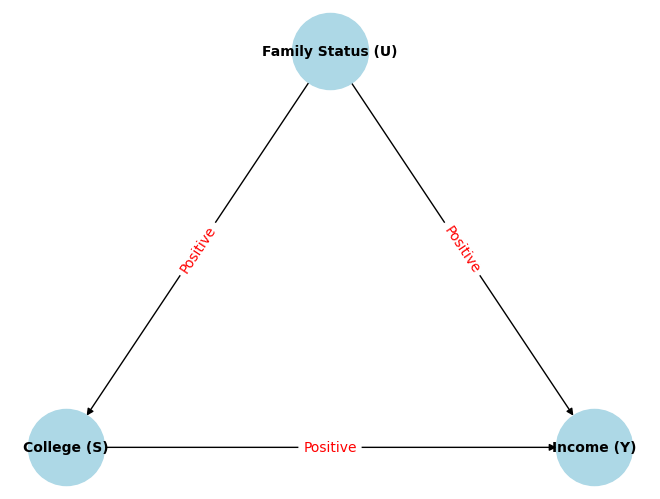

In [7]:
import networkx as nx
import matplotlib.pyplot as plt


# Create a directed graph
G = nx.DiGraph()

# Add nodes
G.add_node("Family Status (U)")
G.add_node("College (S)")
G.add_node("Income (Y)")

# Add directed edges representing causal relationships
G.add_edge("Family Status (U)", "College (S)")
G.add_edge("Family Status (U)", "Income (Y)")
G.add_edge("College (S)", "Income (Y)")

# Draw the graph
pos = {
    "Family Status (U)": (0, 1),
    "College (S)": (-1, 0),
    "Income (Y)": (1, 0),
}

labels = {
    ("Family Status (U)", "College (S)"): "Positive",
    ("Family Status (U)", "Income (Y)"): "Positive",
    ("College (S)", "Income (Y)"): "Positive",
}

nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrows=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_color="red")
plt.show()

Now, let's generate some sythetic data corresponding to this data generative process.

In [8]:
# Step 1: Simulate family status (rich=1, poor=0)
np.random.seed(42)
n = 1000
family_status = np.random.binomial(1, 0.4, n)  # 40% rich, 60% poor

# Step 2: Simulate college attendance based on family status (rich more likely to attend college)
college = np.random.binomial(1, 0.7 * family_status + 0.3 * (1 - family_status), n)

# Step 3: Simulate income based on family status and college attendance

noise = np.random.normal(0, 5000, n)  # Noise to add to income
income_observe = (50000 + 30000 * college + 20000 * family_status + noise)
income_college = (50000 + 30000 * 1 + 20000 * family_status + noise)

# For people who went to college (treated group), compared to the untreated,
# they would have higher income in the counterfactual world where they did not go to college
income_no_college = (50000 + 30000 * 0 + 10000 * college + 20000 * family_status + noise)

# Create a DataFrame for clarity
df = pd.DataFrame({
    'Family_Status': family_status,  # 1 = rich, 0 = poor
    'College': college,  # 1 = went to college, 0 = did not go to college
    'Income_Observe': income_observe,
    'Income_College': income_college,
    'Income_No_College': income_no_college
})

We can calculate the true ATE, ATT, and ATU based on the perfect knowledge we have on the observed and conuterfactual outcomes.

In [9]:
# Step 4: Compute ATE, ATT, ATU
# TRUE ATE:
ATE = df['Income_College'].mean() - df['Income_No_College'].mean()

# ATT:
ATT = df[(df['College'] == 1)]['Income_College'].mean() - df[(df['College'] == 1)]['Income_No_College'].mean()

# ATU:
ATU = df[(df['College'] == 0)]['Income_College'].mean() - df[(df['College'] == 0)]['Income_No_College'].mean()

# Print the results
print(f"TRUE Average Treatment Effect (ATE): {ATE:.2f}")
print(f"TRUE Average Treatment Effect on the Treated (ATT): {ATT:.2f}")
print(f"TRUE Average Treatment Effect on the Untreated (ATU): {ATU:.2f}")

TRUE Average Treatment Effect (ATE): 25560.00
TRUE Average Treatment Effect on the Treated (ATT): 20000.00
TRUE Average Treatment Effect on the Untreated (ATU): 30000.00


What happens if we only have access to the observed treatment and outcome with hidden confounding?

In [16]:
# Step 5: Compute association by conditioning
# Biased ATE using only what was obserevd:
Association = df[df['College'] == 1]['Income_Observe'].mean() - df[df['College'] == 0]['Income_Observe'].mean()

# Print the results
print(f"Biased Average Treatment Effect (ATE): {Association:.2f}")

Biased Average Treatment Effect (ATE): 37639.89


If we have access to potential confounders, we can condition them. Conditional independence helps us here to establish the assumption.

In this example, we ccompute the **association between college attendance and income** within each level of the confounder (family status):

For individuals from **wealthy families** ($F = 1$):

$$
\text{Association}_{F=1} = 
\mathbb{E}[Y \mid S = 1, F = 1] - 
\mathbb{E}[Y \mid S = 0, F = 1]
$$

For individuals from **non-wealthy families** ($F = 0$):

$$
\text{Association}_{F=0} = 
\mathbb{E}[Y \mid S = 1, F = 0] - 
\mathbb{E}[Y \mid S = 0, F = 0]
$$

In [ ]:
# Step 6: Condition on confounder - family status

Association = df[(df['College'] == 1) & (df['Family_Status'] == 1)]['Income_Observe'].mean() - df[(df['College'] == 0) & (df['Family_Status'] == 1)]['Income_Observe'].mean()

# Print the results
print(f"Association for those with family_status = 1: {Association:.2f}")

Association = df[(df['College'] == 1) & (df['Family_Status'] == 0)]['Income_Observe'].mean() - df[(df['College'] == 0) & (df['Family_Status'] == 0)]['Income_Observe'].mean()

# Print the results
print(f"Association for those with family_status = 0: {Association:.2f}")

Association for those with family_status = 1: 30553.75
Association for those with family_status = 0: 30308.08


Without adding the confounder to our regression setup, the result is biased similar to the conditional expectation without conditioning on the confounder.

In [18]:
import statsmodels.formula.api as sm

ols=sm.ols(formula='Income_Observe~College', data=df).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Income_Observe   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     3357.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          1.55e-321
Time:                        14:49:20   Log-Likelihood:                -10649.
No. Observations:                1000   AIC:                         2.130e+04
Df Residuals:                     998   BIC:                         2.131e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.441e+04    432.902    125.692      0.000    5.36e+04    5.53e+04
College     3.764e+04    649.679     57.936      0.000    3.64e+04    3.89e+04
==============================================================================
Omnibus:                       72.502   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.972
Skew:                           0.209   Prob(JB):                     1.88e-07
Kurtosis:                       2.246   Cond. No.                         2.51
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$$
Y = \beta_0 + \beta_1 S + \varepsilon
$$

**Results Summary:**
- **Intercept ($\beta_0 = 54{,}410$):**  
  Represents the **average income** for individuals who did **not** attend college (College = 0).
- **College ($\beta_1 = 37{,}640$):**  
  On average, people who went to college earn **\$37,640 more** than those who did not.
- **$R^2 = 0.771$:**  
  About 77% of the variation in income can be explained by whether someone attended college.

**Interpretation:**
This model captures a **raw association** between college and income.  
It does **not** control for family background, which is a **confounder** influencing both college attendance and income.


We can only identify it by adding the confounder to establish conditional independence.

In [19]:
ols=sm.ols(formula='Income_Observe~College+Family_Status', data=df).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         Income_Observe   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     8981.
Date:                Fri, 24 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:51:08   Log-Likelihood:                -9912.8
No. Observations:                1000   AIC:                         1.983e+04
Df Residuals:                     997   BIC:                         1.985e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      4.996e+04    221.278    225.780      0.000    4.95e+04    5.04e+04
College        3.041e+04    335.519     90.623      0.000    2.97e+04    3.11e+04
Family_Status   1.98e+04    342.263     57.864      0.000    1.91e+04    2.05e+04
==============================================================================
Omnibus:                        1.170   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.557   Jarque-Bera (JB):                1.054
Skew:                           0.025   Prob(JB):                        0.590
Kurtosis:                       3.151   Cond. No.                         3.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

$$
Y = \beta_0 + \beta_1 S + \beta_2 F + \varepsilon
$$

**Results Summary:**
- **Intercept ($\beta_0 = 49{,}960$):**  
  Baseline income for someone from a **poor family** ($F = 0$) who did **not** attend college.
- **College ($\beta_1 = 30{,}410$):**  
  Holding family status constant, going to college increases income by about **\$30,410**.  
  This matches the **true causal effect** in the data-generating process.
- **Family_Status ($\beta_2 = 19{,}800$):**  
  Controlling for college, being from a wealthy family adds about **\$19,800** to income.  
  This coefficient is **descriptive**, not causal.
- **$R^2 = 0.947$:**  
  The model now explains 95% of the variation in income — a much better fit.

Now, college attendance ($S$) is **conditionally independent** of unobserved factors ($U$) given $F$. Within each family type (rich or poor), the treatment is **as-if random**, allowing us to recover the causal effect.

**Conclusion:**
This regression is **causal** (in this simulation).  
The coefficient on `College` reflects the **true causal effect** of college on income, while the coefficient on `Family_Status` remains **descriptive**.